Create a TS+biology tracers initial file for one bathymetry based on a restart file from a different bathymetry

In [1]:
import netCDF4 as nc
import xarray as xr
import numpy as np 

from salishsea_tools import nc_tools

%matplotlib inline

# New Bathymetry (via its mesh mask)

In [4]:
mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc')
mbathy = mesh.variables['mbathy'][0,:,:]
#used to calculate number of vertical ocean grid cells at each (i,j) (1=land point)
gdepw = mesh.variables['gdepw_0'][0,:,:,:]
surface_tmask = mesh.variables['tmask'][0,0,:,:]
surface_tmask = np.abs(surface_tmask-1)
tmask = mesh.variables['tmask'][0,:,:,:]
tmask = np.abs(tmask-1)
lats = mesh.variables['nav_lat'][:]
lons = mesh.variables['nav_lon'][:]
mesh.close()

In [5]:
# calculate bathymetry based on meshmask
NEMO_bathy = np.zeros(mbathy.shape)
for i in range(NEMO_bathy.shape[1]):
    for j in range(NEMO_bathy.shape[0]):
        level = mbathy[j,i]
        NEMO_bathy[j,i] = gdepw[level,j,i]
NEMO_bathy = np.ma.masked_array(NEMO_bathy, mask = surface_tmask)

# Old Bathymetry (based on its mesh mask)

In [6]:
oldmesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
oldmbathy =oldmesh.variables['mbathy'][0,:,:] 
#used to calculate number of vertical ocean grid cells at each (i,j) (1=land point)
oldgdepw = oldmesh.variables['gdepw_0'][0,:,:,:]
oldsurface_tmask = oldmesh.variables['tmask'][0,0,:,:]
oldsurface_tmask = np.abs(oldsurface_tmask-1)
oldtmask = oldmesh.variables['tmask'][0,:,:,:]
oldtmask = np.abs(oldtmask-1)
oldmesh.close()

In [7]:
np.max(oldmbathy)

39

# Restart Files to Get Tracers (TS and Biology)

In [8]:
dataphys = nc.Dataset('/results2/SalishSea/nowcast-green.202111/31dec09/SalishSea_06324480_restart.nc')
databio = nc.Dataset('/results2/SalishSea/nowcast-green.202111/31dec09/SalishSea_06324480_restart_trc.nc')   

In [9]:
physical = ['tn', 'sn',
           'tb', 'sb']
biological = ['TRNDON', 'TRNMICZ','TRNMYRI','TRNNH4','TRNNO3','TRNTRA',
              'TRNPHY','TRNDIAT','TRNPON','TRNSi','TRNbSi',
              'TRNDIC', 'TRNTA', 'TRNO2',
             'TRBDON', 'TRBMICZ','TRBMYRI','TRBNH4','TRBNO3','TRBTRA',
              'TRBPHY','TRBDIAT','TRBPON','TRBSi','TRBbSi',
             'TRBDIC', 'TRBTA', 'TRBO2']
varas = {}
for vb in physical:
    varas[vb] = dataphys.variables[vb][0, :]
for vb in biological:
    print (vb)
    varas[vb] = databio.variables[vb][0, :]
#dataphys.close()
#databio.close()
varall = physical + biological

TRNDON
TRNMICZ
TRNMYRI
TRNNH4
TRNNO3
TRNTRA
TRNPHY
TRNDIAT
TRNPON
TRNSi
TRNbSi
TRNDIC
TRNTA
TRNO2
TRBDON
TRBMICZ
TRBMYRI
TRBNH4
TRBNO3
TRBTRA
TRBPHY
TRBDIAT
TRBPON
TRBSi
TRBbSi
TRBDIC
TRBTA
TRBO2


# Fill in any Missing Data Points

In [10]:
def find_mean(varas, varall, i, j, k, dd, oldtmask):
    for vb in varall:
        imin = max(i-dd, 0)
        imax = min(i+dd, 897)
        jmin = max(j-dd, 0)
        jmax = min(j+dd, 397)
        temporary = np.sum(varas[vb][k, imin:imax+1, jmin:jmax+1]*(1-oldtmask[k, imin:imax+1, jmin:jmax+1]))
        count = np.sum(1-oldtmask[k, imin:imax+1, jmin:jmax+1])
        if count == 0:
            varas[vb][k, i, j] = 0
        else:
            varas[vb][k, i, j] = temporary/count
    return varas

In [11]:
def fillit(kmax, oldtmask, varas, varall):
    dd = 1
    bad = 1
    while bad > 0:
        dd += 1
        good = 1
        while good > 0:
            good = 0; bad = 0; already = 0
            for k in range(kmax+1):
                for i in range(1, 898):
                    for j in range(1, 398):
                        if tmask[k,i,j] < oldtmask[k,i,j]:
                            if varas['sn'][k, i, j] > 0:
                                already = already + 1
                            else:
                                varas = find_mean(varas, varall, i, j, k, dd, oldtmask)
                                if varas['sn'][k, i, j] > 0:
                                    good = good + 1
                                else:
                                    bad = bad + 1
                                    if dd > 5:
                                        print (k, i, j)
            print ('dd', dd, 'good', good)
            print ('already', already, 'bad', bad)

This can take a very long time if the bathymetries are very different, aka add a new long river.  If you want you can do it in pieces by starting with the first argument at say 5 and then slowly increasing it.  You do need to go to 39 finally. For new bathy201702 versus old bathy201702 its fast.

In [12]:
fillit(39, oldtmask, varas, varall)

dd 2 good 192
already 0 bad 91
dd 2 good 0
already 192 bad 91
dd 3 good 24
already 192 bad 67
dd 3 good 0
already 216 bad 67
dd 4 good 18
already 216 bad 49
dd 4 good 0
already 234 bad 49
dd 5 good 12
already 234 bad 37
dd 5 good 0
already 246 bad 37
26 361 240
26 362 218
26 362 219
26 363 218
26 363 219
26 363 220
26 363 221
26 363 235
26 363 236
26 363 237
26 363 238
26 363 239
26 363 240
26 364 221
26 364 235
26 364 236
26 364 237
26 364 238
26 364 239
26 364 240
26 365 239
26 365 240
27 361 228
27 362 228
dd 6 good 13
already 246 bad 24
26 361 240
26 362 218
26 362 219
26 363 218
26 363 219
26 363 220
26 363 221
26 363 235
26 363 236
26 363 237
26 363 238
26 363 239
26 363 240
26 364 221
26 364 235
26 364 236
26 364 237
26 364 238
26 364 239
26 364 240
26 365 239
26 365 240
27 361 228
27 362 228
dd 6 good 0
already 259 bad 24
26 362 219
26 363 219
26 363 220
26 363 236
26 363 237
26 363 238
26 363 239
26 364 236
26 364 237
26 364 238
26 364 239
26 365 239
27 361 228
27 362 228
dd 7

# Write Initial File

In [15]:
# build nc file
new_initialfile = nc.Dataset('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_phybio_06324480_31dec09.nc', 'w')
nc_tools.init_dataset_attrs(
    new_initialfile, 
    title='All tracers for Bathymetry 202310b from nowcast-green 31dec09, with N and Si inc.', 
    notebook_name='/ocean/atall/MOAD/analysis-abdoul/notebooks/bathy/Initial_from_Restart_Bathy202310_Spinup31Dec2009', 
    nc_filepath='/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_phybio_06324480_31dec09.nc',
    comment='All Tracers, physical and biological')
new_initialfile.createDimension('y', 898)
new_initialfile.createDimension('x', 398)
new_initialfile.createDimension('z', 40)
new_initialfile.createDimension('t', None)

file format: NETCDF4
Conventions: CF-1.6
title: All tracers for Bathymetry 202310b from nowcast-green 31dec09, with N and Si inc.
institution: Dept of Earth, Ocean & Atmospheric Sciences, University of British Columbia
source: REQUIRED
references: REQUIRED
history: [2024-10-10 12:31:01] Created netCDF4 zlib=True dataset.
comment: All Tracers, physical and biological


*** failed to import extension hgext.qct: No module named qct
not found!


<class 'netCDF4._netCDF4.Dimension'> (unlimited): name = 't', size = 0

In [16]:
thevara = {}
for vb in varall:
    thevara[vb] = new_initialfile.createVariable(
        vb, 'float64', ('t', 'z', 'y', 'x'), zlib=True,
        least_significant_digit=1e-5, fill_value=-99)
    thevara[vb][0] = varas[vb]
    print (vb, np.max(thevara[vb]))
new_initialfile

tn 11.125
sn 34.0625
tb 11.125
sb 34.0625
TRNDON 0.625
TRNMICZ 0.4375
TRNMYRI 0.0
TRNNH4 4.5
TRNNO3 38.5
TRNTRA 13.9375
TRNPHY 0.4375
TRNDIAT 0.5
TRNPON 0.25
TRNSi 124.4375
TRNbSi 12.1875
TRNDIC 2302.9375
TRNTA 2325.1875
TRNO2 366.125
TRBDON 0.625
TRBMICZ 0.4375
TRBMYRI 0.0
TRBNH4 4.5
TRBNO3 38.5
TRBTRA 13.9375
TRBPHY 0.4375
TRBDIAT 0.5
TRBPON 0.25
TRBSi 124.25
TRBbSi 12.1875
TRBDIC 2302.9375
TRBTA 2325.1875
TRBO2 366.125


<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.6
    title: All tracers for Bathymetry 202310b from nowcast-green 31dec09, with N and Si inc.
    institution: Dept of Earth, Ocean & Atmospheric Sciences, University of British Columbia
    source: REQUIRED
    references: REQUIRED
    history: [2024-10-10 12:31:01] Created netCDF4 zlib=True dataset.
    comment: All Tracers, physical and biological
    dimensions(sizes): y(898), x(398), z(40), t(1)
    variables(dimensions): float64 tn(t, z, y, x), float64 sn(t, z, y, x), float64 tb(t, z, y, x), float64 sb(t, z, y, x), float64 TRNDON(t, z, y, x), float64 TRNMICZ(t, z, y, x), float64 TRNMYRI(t, z, y, x), float64 TRNNH4(t, z, y, x), float64 TRNNO3(t, z, y, x), float64 TRNTRA(t, z, y, x), float64 TRNPHY(t, z, y, x), float64 TRNDIAT(t, z, y, x), float64 TRNPON(t, z, y, x), float64 TRNSi(t, z, y, x), float64 TRNbSi(t, z, y, x), float64 TRNDIC(t, z, y, x), float64 TRNTA(t, z, y, x),

In [17]:
new_initialfile.close()

# Copy variables from the old restart files to the new one and correct salinity

In [18]:
var_phy_to_copy = {'nav_lon','nav_lat','nav_lev','time_counter','rnf_b', 'sfx_b', 'rotn', 'vtau_b', 'rdttra1', 'avt', 'nav_lon', 'qns_b', 'vn', 'hdivn', 'time_counter', 'en', 'hdivb', 'sshb', 'rhop', 'ndastp', 'adatrj', 'fse3t_n', 'ssh_ibb', 'avm', 'avmu', 'mxln', 'sshn', 'sbc_sc_b', 'nav_lev', 'emp_b', 'qsr_hc_b', 'sbc_hc_b', 'rnf_sc_b', 'vb2_b', 'ub2_b', 'nav_lat', 'ub', 'rotb', 'fse3t_b', 'un', 'rdt', 'utau_b', 'fraqsr_1lev', 'avmv', 'vb', 'kt', 'rnf_hc_b'}
var_bio_to_copy = {'rnf_pis_DIC_b', 'rnf_pis_MYRI_b', 'sbc_DON_b', 'sbc_bSi_b', 'nav_lon', 'rnf_pis_PON_b', 'rnf_pis_PHY_b', 'time_counter', 'rnf_pis_MICZ_b', 'sbc_TA_b', 'rdttrc1', 'rnf_pis_TRA_b', 'ndastp', 'sbc_Si_b', 'rnf_pis_TA_b', 'adatrj', 'rnf_pis_bSi_b', 'sbc_PHY_b', 'nav_lev', 'sbc_DIC_b', 'sbc_DIAT_b', 'sbc_O2_b', 'sbc_MYRI_b', 'rnf_pis_NO3_b', 'rnf_pis_DON_b', 'sbc_MICZ_b', 'sbc_PON_b', 'sbc_NH4_b', 'rnf_pis_O2_b', 'nav_lat', 'sbc_TRA_b', 'kt', 'rnf_pis_DIAT_b', 'rnf_pis_Si_b', 'rnf_pis_NH4_b', 'sbc_NO3_b'}

In [19]:
dfphy = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/31dec09/SalishSea_06324480_restart.nc') 
dfbio = xr.open_dataset('/results2/SalishSea/nowcast-green.202111/31dec09/SalishSea_06324480_restart_trc.nc') 
dfnew = xr.open_dataset('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_phybio_06324480_31dec09.nc')

In [20]:
dfnew[var_phy_to_copy]=dfphy[var_phy_to_copy]
dfnew[var_bio_to_copy]=dfbio[var_bio_to_copy]
dfnew

<xarray.Dataset>
Dimensions:         (t: 1, z: 40, y: 898, x: 398)
Dimensions without coordinates: t, z, y, x
Data variables: (12/104)
    tn              (t, z, y, x) float64 ...
    sn              (t, z, y, x) float64 ...
    tb              (t, z, y, x) float64 ...
    sb              (t, z, y, x) float64 ...
    TRNDON          (t, z, y, x) float64 ...
    TRNMICZ         (t, z, y, x) float64 ...
    ...              ...
    rnf_pis_O2_b    (t, y, x) float64 ...
    sbc_NH4_b       (t, y, x) float64 ...
    rnf_pis_NO3_b   (t, y, x) float64 ...
    sbc_bSi_b       (t, y, x) float64 ...
    sbc_TA_b        (t, y, x) float64 ...
    sbc_DIC_b       (t, y, x) float64 ...
Attributes:
    Conventions:  CF-1.6
    title:        All tracers for Bathymetry 202310b from nowcast-green 31dec...
    institution:  Dept of Earth, Ocean & Atmospheric Sciences, University of ...
    source:       REQUIRED
    references:   REQUIRED
    history:      [2024-10-10 12:31:01] Created netCDF4 zlib=True dataset.
    comment:      All Tracers, physical and biological

In [21]:
dfnew.to_netcdf('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_PHYBIO_06324480_31dec09_bathy202310b.nc', mode='w')

In [22]:
#
Sn = dfnew.variables['sn']
Sb = dfnew.variables['sb']
Sn.shape

(1, 40, 898, 398)

In [23]:
kk = np.arange(1, 40)
jj = np.arange(0, 898)
ii = np.arange(0, 398)
# box where changes took place (in all salish sea takes too much time, and not necessary I think)
pointsi = np.arange(200, 250).astype(int)
pointsj = np.arange(350, 380).astype(int)

#SSn = np.ones((1, 40, 898, 398))
for k in kk:
    for j in pointsj:
        for i in pointsi:
            diffsn = Sn[:, k, j, i] - Sn[:, k-1, j, i]
            if diffsn < 0:
                Sn[:, k, j, i] = Sn[:, k-1, j, i]
#            else:
#                sn[:, k, j, i] = sn[:, k, j, i]

Sn.shape


(1, 40, 898, 398)

In [24]:
for k in kk:
    for j in pointsj:
        for i in pointsi:
            diffsb = Sb[:, k, j, i] - Sb[:, k-1, j, i]
            if diffsb < 0:
                Sb[:, k, j, i] = Sb[:, k-1, j, i]

Sb.shape

(1, 40, 898, 398)

In [25]:
dfnew2 = dfnew
dfnew2['sn'] = Sn
dfnew2['sb'] = Sb


In [26]:
dfnew2.to_netcdf('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_PHYBIO_06324480_31dec09_bathy202310b_snsbCorrected.nc', mode='w')

In [27]:
dfA = xr.open_dataset('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_PHYBIO_06324480_31dec09_bathy202310b.nc')
dfB = xr.open_dataset('/ocean/atall/MOAD/Model/runs/restart/31dec09/restart_PHYBIO_06324480_31dec09_bathy202310b_snsbCorrected.nc')
snA = dfA['sn']
snB = dfB['sn']

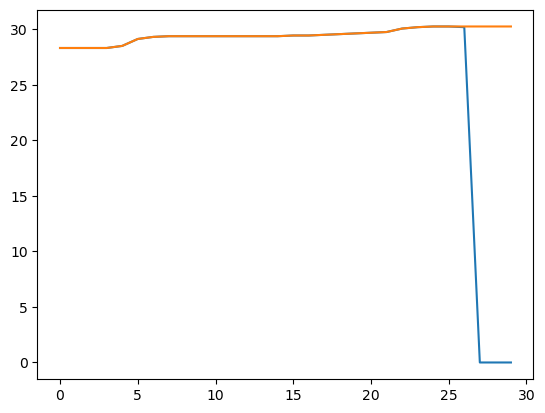

In [28]:
import matplotlib.pyplot as plt
plt.plot(snA[0, :30, 363, 235])
plt.plot(snB[0, :30, 363, 235])
